In [2]:
# Calculate the coefficient of variation of each barcode across the 15 rows of each enhancer
def cv(x):
    return x.std() / x.mean()

def get_std_mean(matched_barcodes):
    matched_barcodes =matched_barcodes.reset_index()
    if 'ID' in matched_barcodes.columns:
        matched_barcodes = matched_barcodes.drop(["ID"],axis=1)
        barcode_stats = matched_barcodes.groupby(matched_barcodes.index // 15).agg(cv)
    elif 'Pseudo-barcode' in matched_barcodes.columns:
        matched_barcodes = matched_barcodes.drop(["Pseudo-barcode"],axis=1)
        barcode_stats = matched_barcodes.groupby(matched_barcodes.index // 5).agg(cv)        
    else:
        print('get_std_mean(matched_barcodes) error')
    return barcode_stats

import pandas as pd

def process_and_plot_data(rna_file_path, dna_file_path, enhancer_drop_file_path):
    # Read the RNA and DNA matched files
    RNA_matched = pd.read_csv(rna_file_path, index_col=0)
    DNA_matched = pd.read_csv(dna_file_path, index_col=0)

    # Read the enhancer to drop file
    enhancer_to_drop = pd.read_csv(enhancer_drop_file_path, index_col=0)
    enhancer_to_drop = enhancer_to_drop[enhancer_to_drop["Drop"] == "Y"].index

    # Filter out the dropped enhancers and drop the 'enhancer_id' column
    RNA_matched = RNA_matched[~RNA_matched['enhancer_id'].isin(enhancer_to_drop)].drop(["enhancer_id"], axis=1)
    DNA_matched = DNA_matched[~DNA_matched['enhancer_id'].isin(enhancer_to_drop)].drop(["enhancer_id"], axis=1)

    return RNA_matched, DNA_matched
# Example usage
#process_and_plot_data('/path/to/RNA_matched.csv', '/path/to/DNA_matched.csv', '/path/to/enhancer_to_drop.csv')


def plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=200,y_lim = 5):
    DNA_matched = DNA_matched.rename(columns=lambda x: x[:-2] if x.endswith('_R') else x)
    RNA_matched = RNA_matched.rename(columns=lambda x: x[:-2] if x.endswith('_R') else x)
    d_rna = get_std_mean(RNA_matched.fillna(0))
    d_dna = get_std_mean(DNA_matched.fillna(0))

    sns.set_style("white")

    # Calculate the figure width dynamically based on the number of x elements
    num_x_elements = max(len(d_rna.columns), len(d_dna.columns))
    fig_width = num_x_elements * width_per_element

    # Create a figure with two subplots
    fig, axs = plt.subplots(nrows=2, figsize=(fig_width, height), sharex=True, dpi=dpi)

    # Plot the violin plot for the RNA dataset in the first subplot
    sns.violinplot(data=d_rna, ax=axs[0])
    axs[0].set_ylabel('Standard deviation/Mean')
    axs[0].set_title('RNA Dataset')
    axs[0].set_ylim(0, y_lim)

    # Plot the violin plot for the DNA dataset in the second subplot
    sns.violinplot(data=d_dna, ax=axs[1])
    axs[1].set_ylabel('Standard deviation/Mean')
    axs[1].set_title('DNA Dataset')
    axs[1].set_ylim(0, y_lim)

    # Add horizontal lines to the plot
    #for i in [1.5, 10.5, 18.5, 21.5]:
    #    axs[0].axvline(x=i, color='red', linestyle=':', linewidth=1.2)
    #    axs[1].axvline(x=i, color='red', linestyle=':', linewidth=1.2)

    plt.xticks(rotation=90)

    # Remove the top and right spines from each subplot
    sns.despine(ax=axs[0], top=True, right=True)
    sns.despine(ax=axs[1], top=True, right=True)

    # Show the plot
    plt.show()

    import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_nan(matched_barcodes, label=None):
    # Count the number of non-NaN values in every 15 rows
    #counts = matched_barcodes.notnull().groupby(np.arange(len(matched_barcodes)) // 15).sum()
    counts = (matched_barcodes > 0).groupby(np.arange(len(matched_barcodes)) // 15).sum()
    # Calculate the mean and standard error of the counts for each column
    mean_counts = counts.mean()
    se_counts = sem(counts)
    plt.errorbar(x=mean_counts / 15, y=np.arange(len(mean_counts)), xerr=se_counts / 15, fmt='o', label=label)


def plot_barcodes_dropout(RNA_matched, DNA_matched, height_per_sample=0.4, width=6, dpi=200):
    # Determine the number of samples (maximum of RNA and DNA matched samples)
    num_samples = max(len(RNA_matched.columns), len(DNA_matched.columns))

    # Adjust figure height based on the number of samples
    fig_height = num_samples * height_per_sample

    plt.figure(figsize=(width, fig_height), dpi=dpi)
    sns.set(style='whitegrid')

    index = []
    total_reads = (RNA_matched.sum() / 1000000)
    for i in range(len(RNA_matched.columns)):
        index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")

    # Plot the data for the RNA and DNA datasets with labels
    plot_nan(RNA_matched, label='RNA_matched')
    plot_nan(DNA_matched, label='DNA_matched')

    # Set the y-axis labels to the enhancer names
    plt.yticks(np.arange(len(index)), index)

    # Add the x-axis label and title to the plot
    plt.xlabel('Percentage of Non-NaN Values')
    plt.title('Mean Percentage of Non-NaN Values in every 15 barcodes (one enhancer)')
    plt.xlim(0, 1.)

    # Add a legend to the plot
    plt.legend(bbox_to_anchor=(1.02, 1.01), loc='upper left')

    # Add horizontal lines to the plot
    #for i in [1.5, 10.5, 18.5, 21.5]:
    #    plt.axhline(y=i, color='red', linestyle=':', linewidth=1.2)
    
    # Show the plot
    plt.show()

# Example usage
# plot_barcodes_dropout(RNA_matched_data, DNA_matched_data)


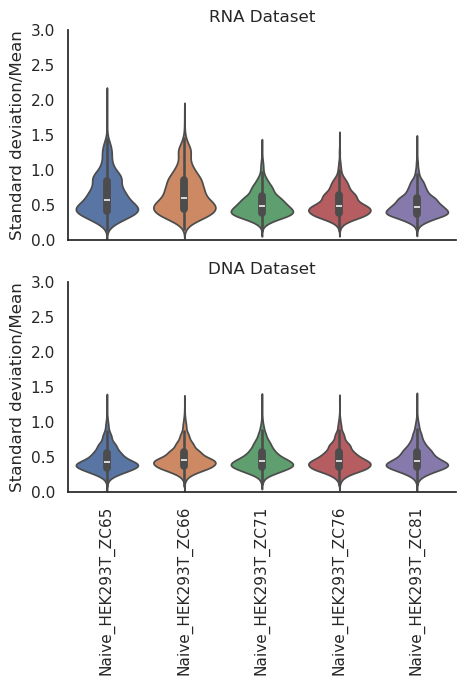

/tmp/ipykernel_21094/2059592520.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


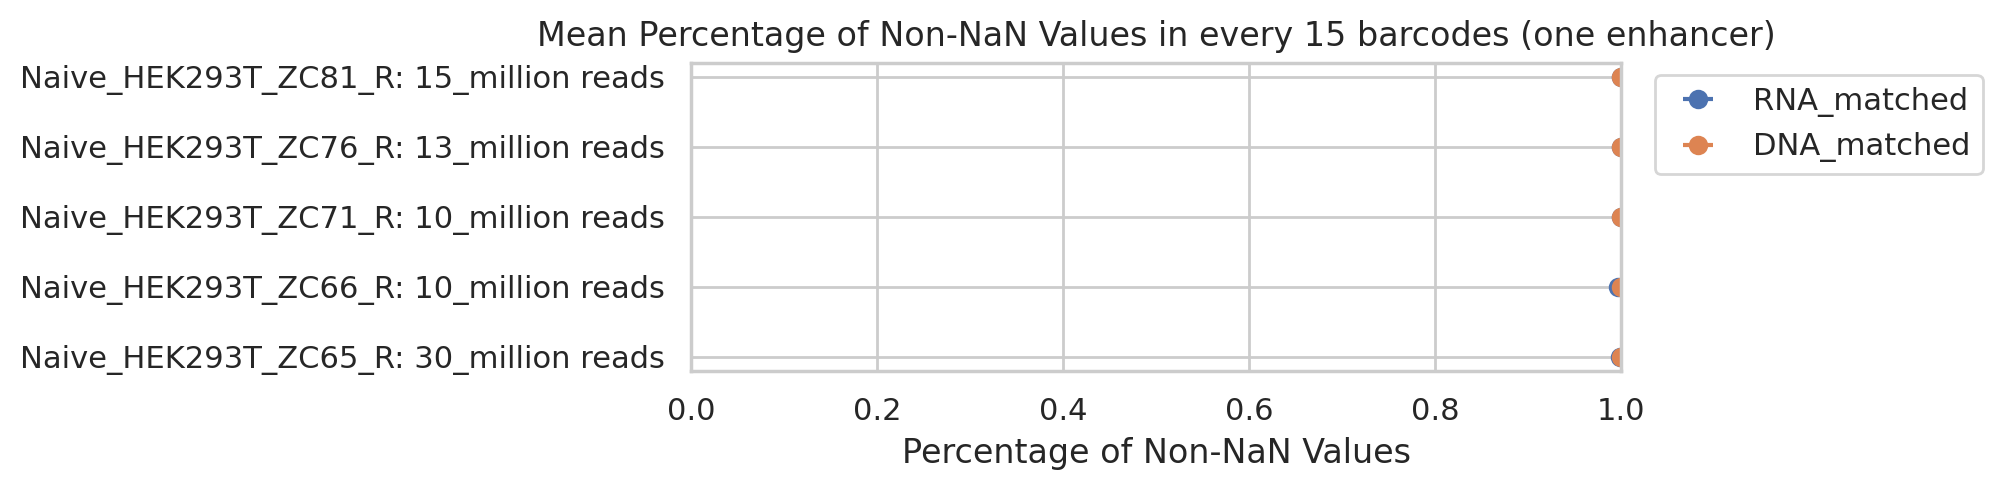

In [3]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/HEK293T_RNA_matched_barcodes.csv', 
    dna_file_path = 'read_counts_R1R2/HEK293T_DNA_matched_barcodes.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 3)
plot_barcodes_dropout(RNA_matched, DNA_matched)

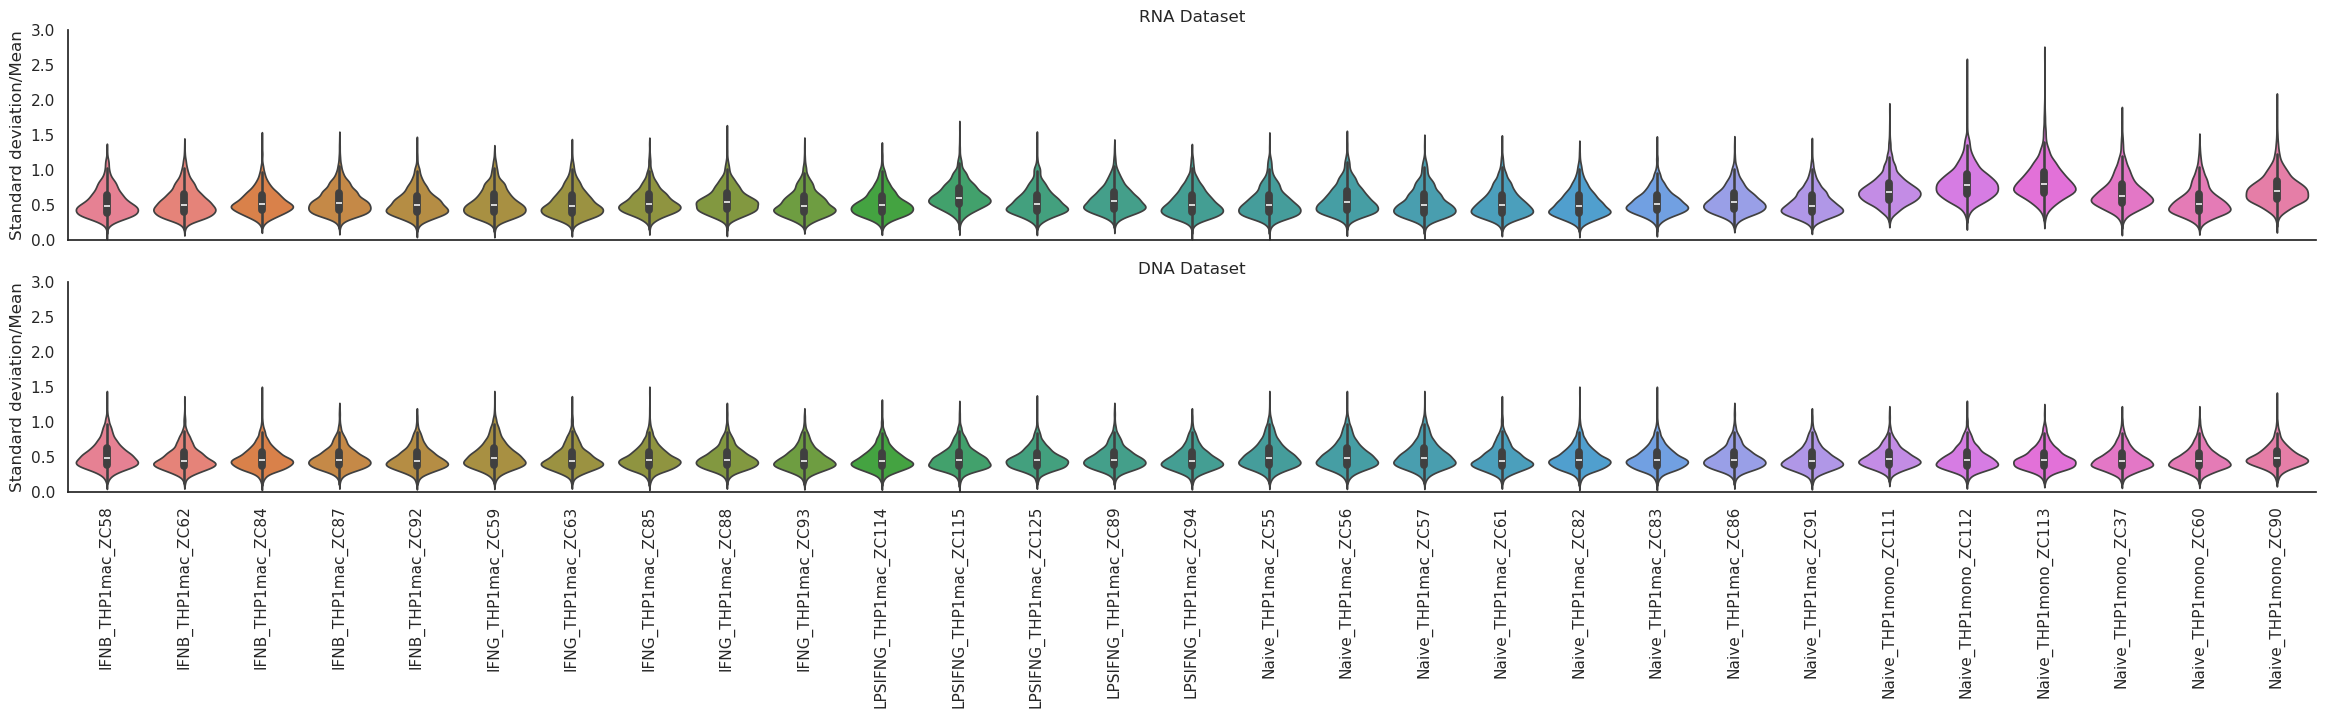

/tmp/ipykernel_21094/2059592520.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


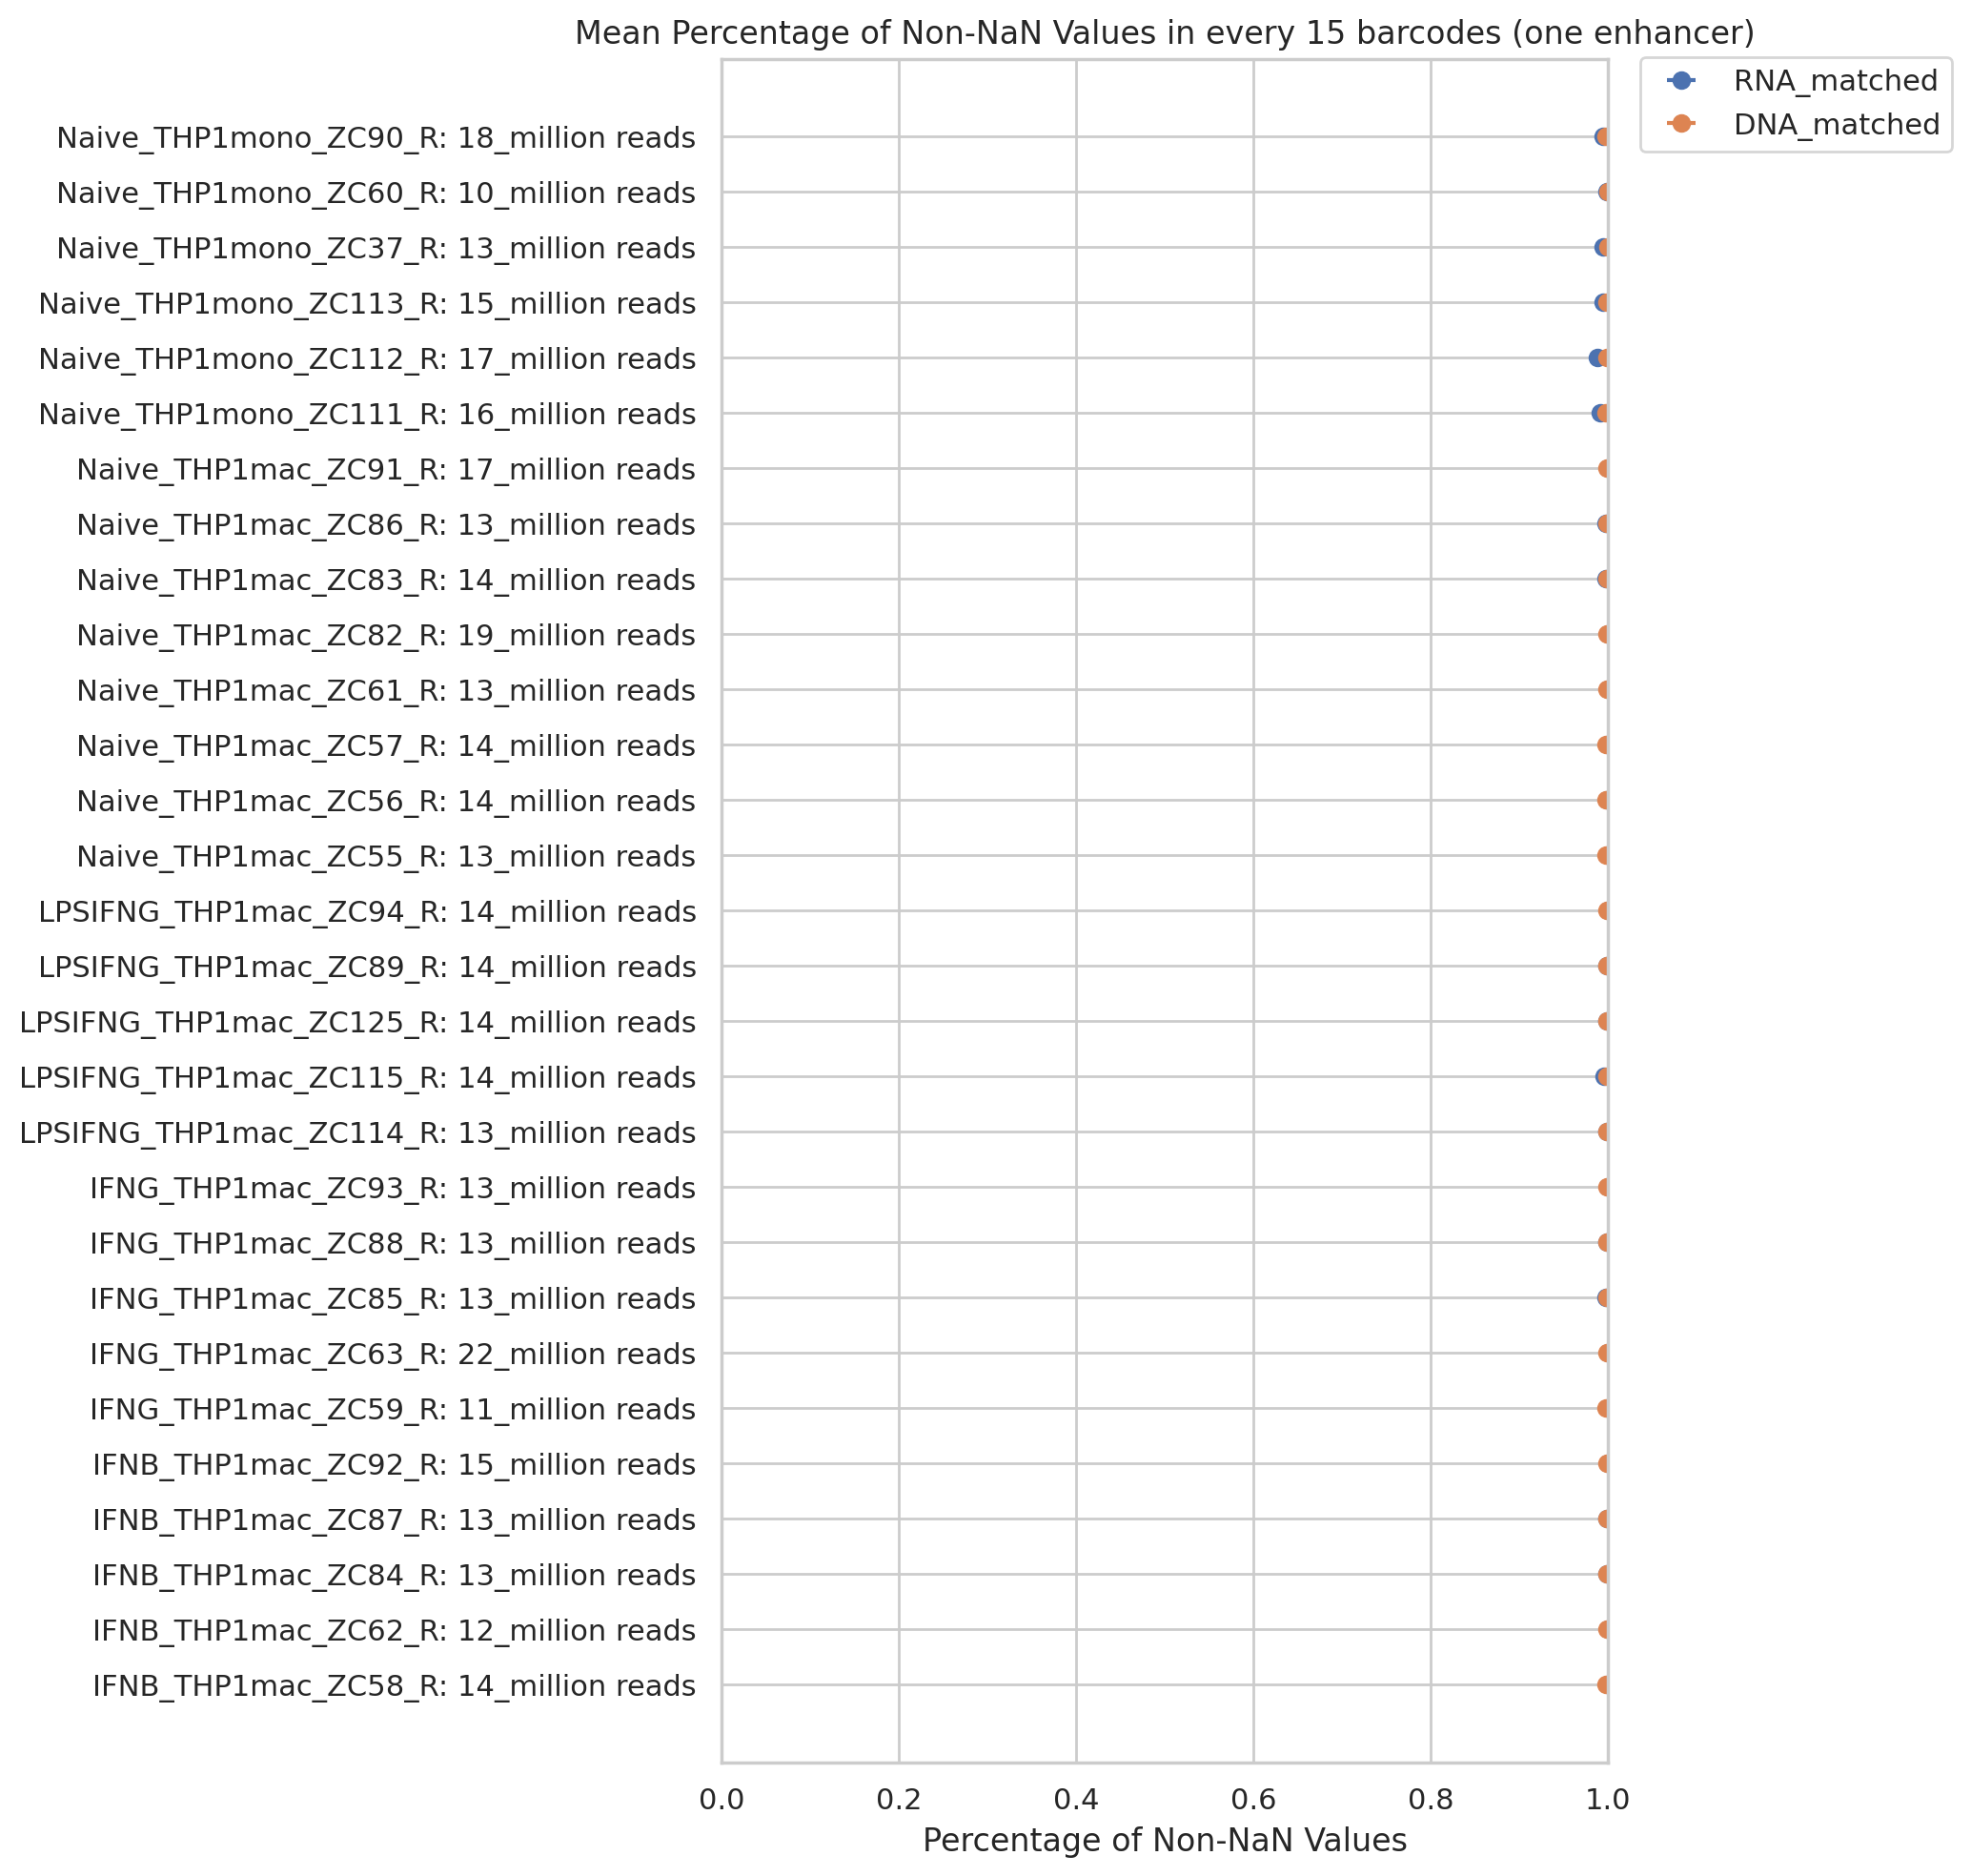

In [8]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/THP1_RNA_matched_barcodes.csv', 
    dna_file_path = 'read_counts_R1R2/THP1_DNA_matched_barcodes.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 3)
plot_barcodes_dropout(RNA_matched, DNA_matched)

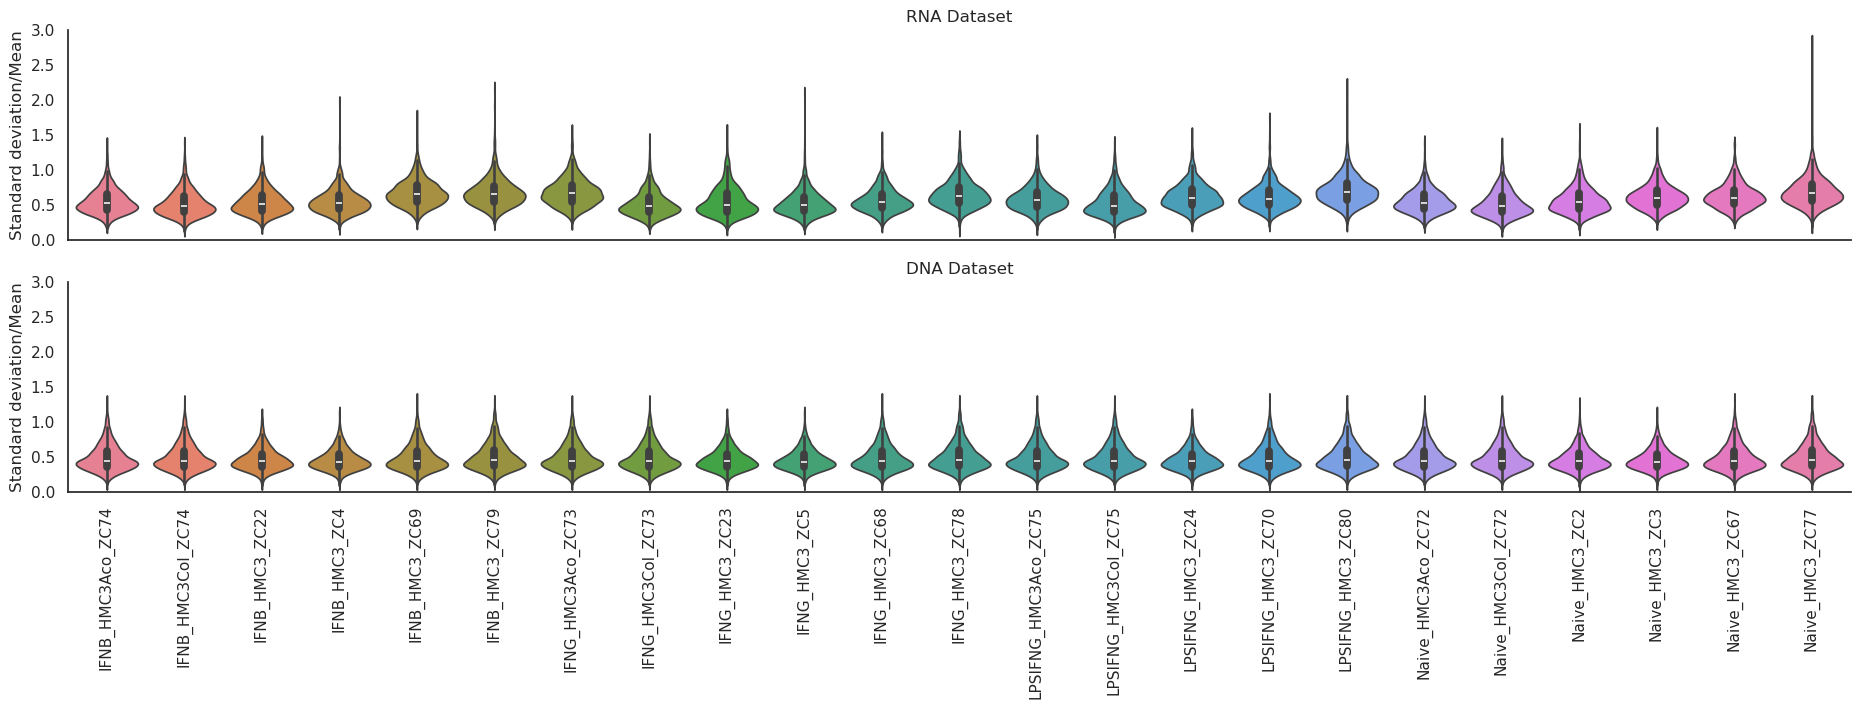

/tmp/ipykernel_21094/2059592520.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


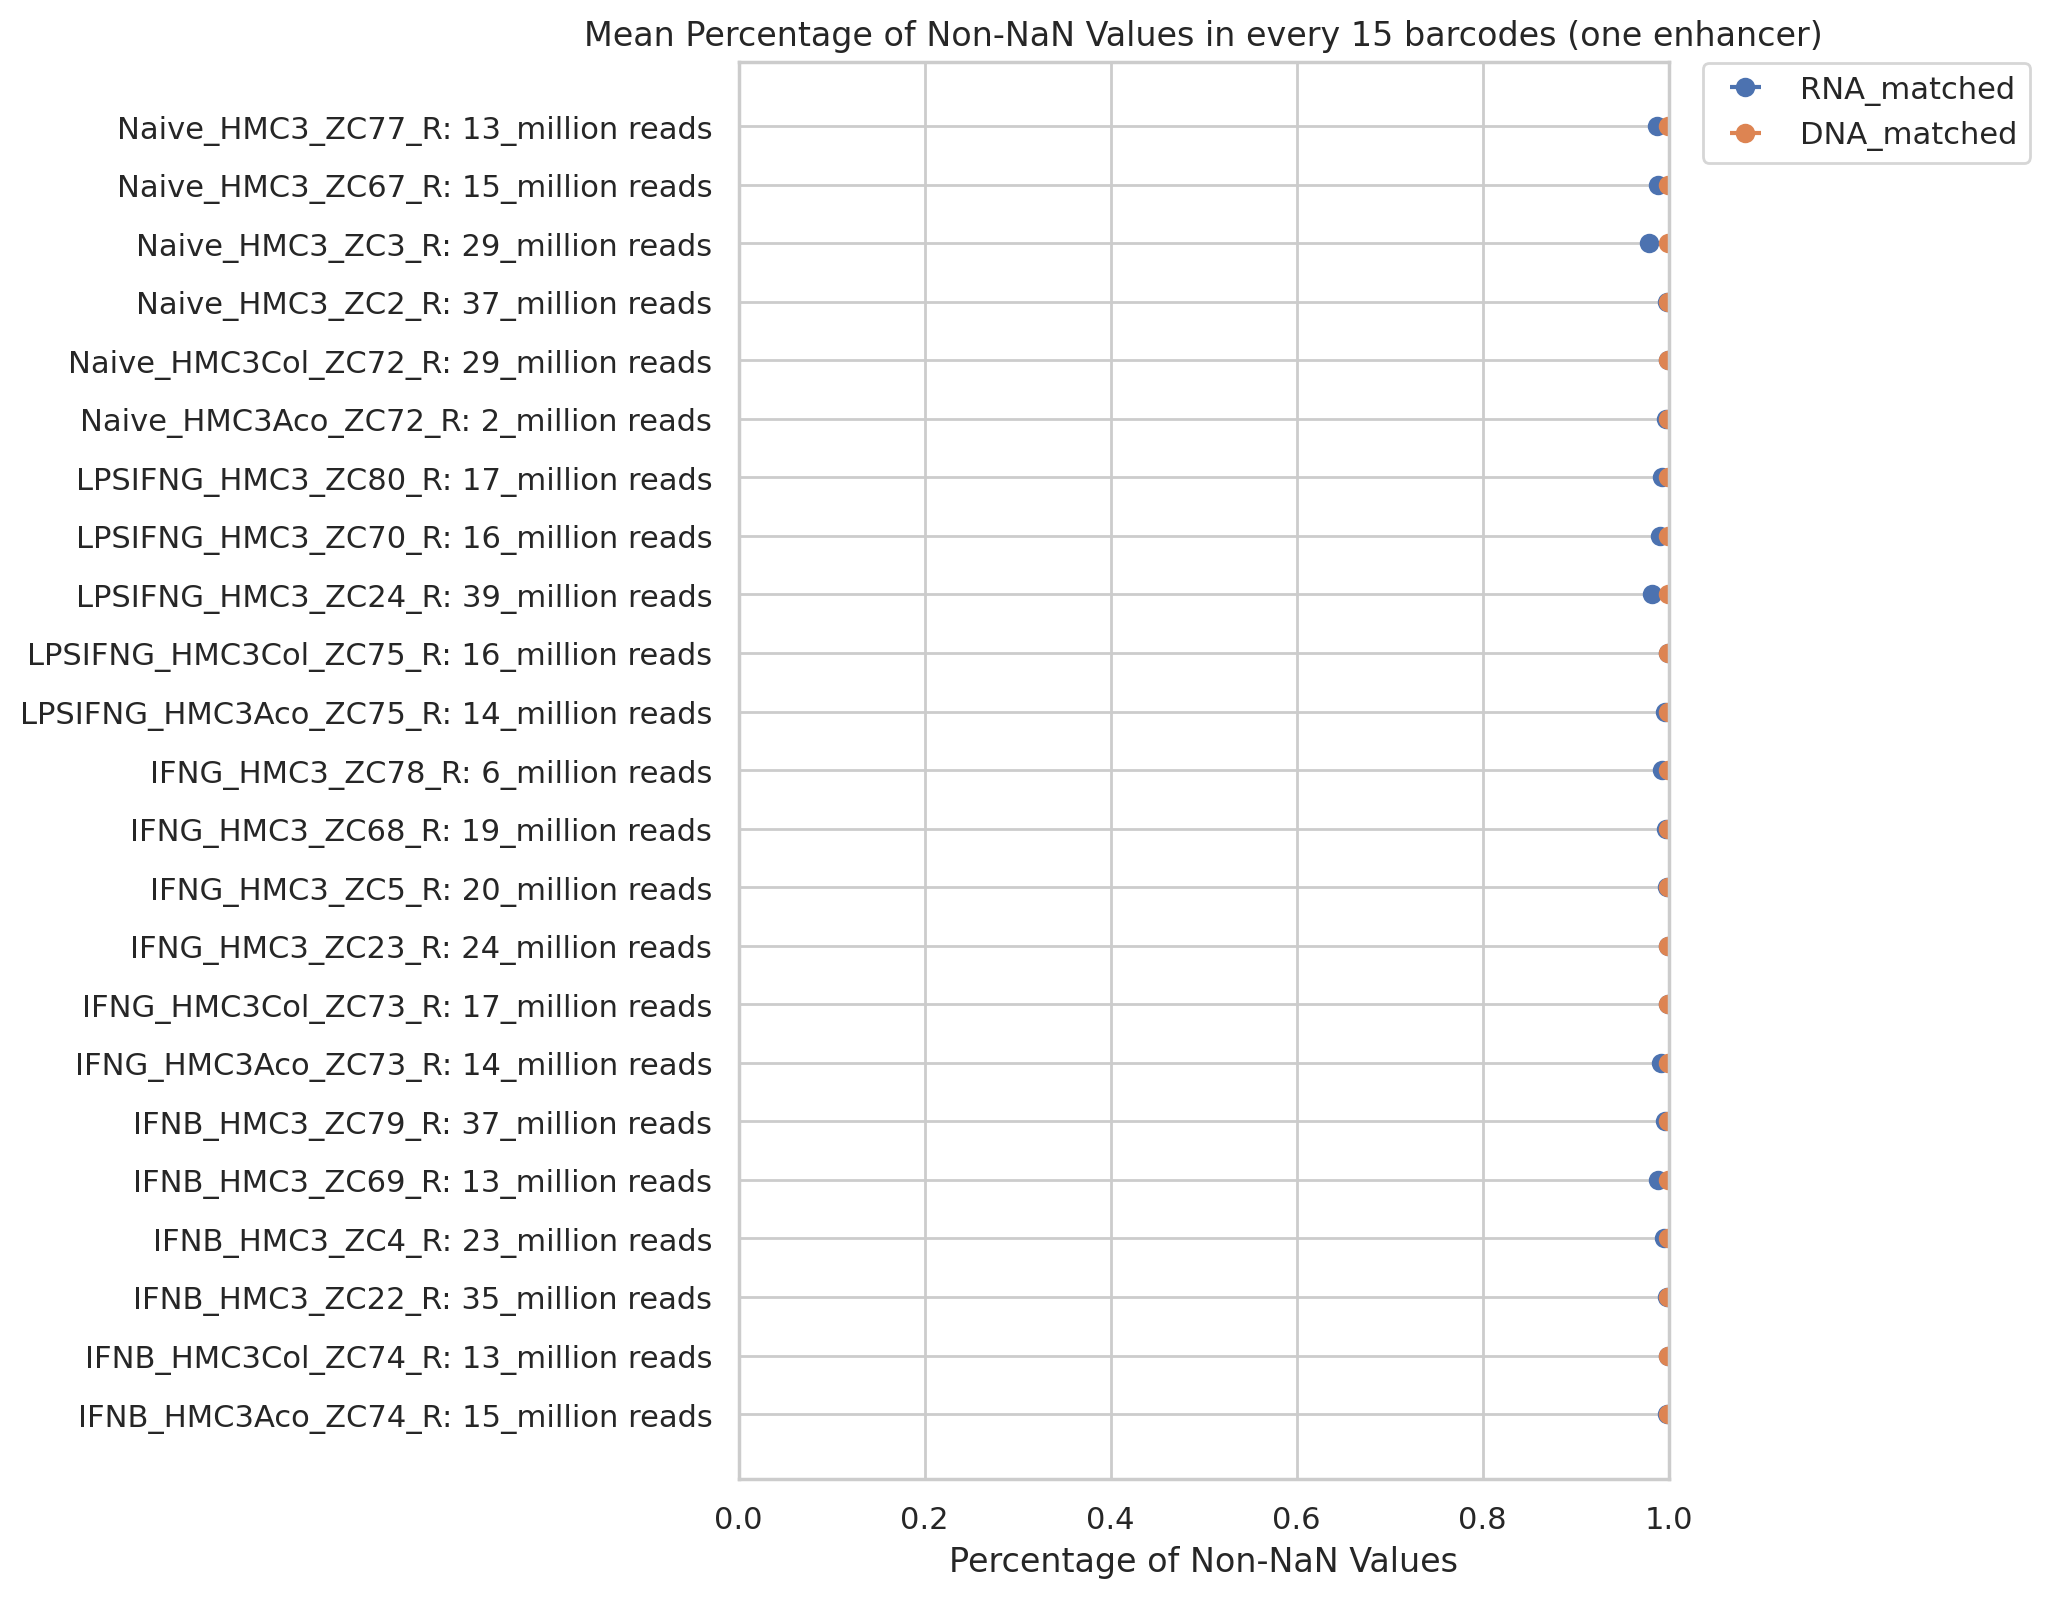

In [7]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/HMC3_RNA_matched_barcodes.csv', 
    dna_file_path = 'read_counts_R1R2/HMC3_DNA_matched_barcodes.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 3)
plot_barcodes_dropout(RNA_matched, DNA_matched)

/tmp/ipykernel_21094/2059592520.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return x.std() / x.mean()
/tmp/ipykernel_21094/2059592520.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return x.std() / x.mean()


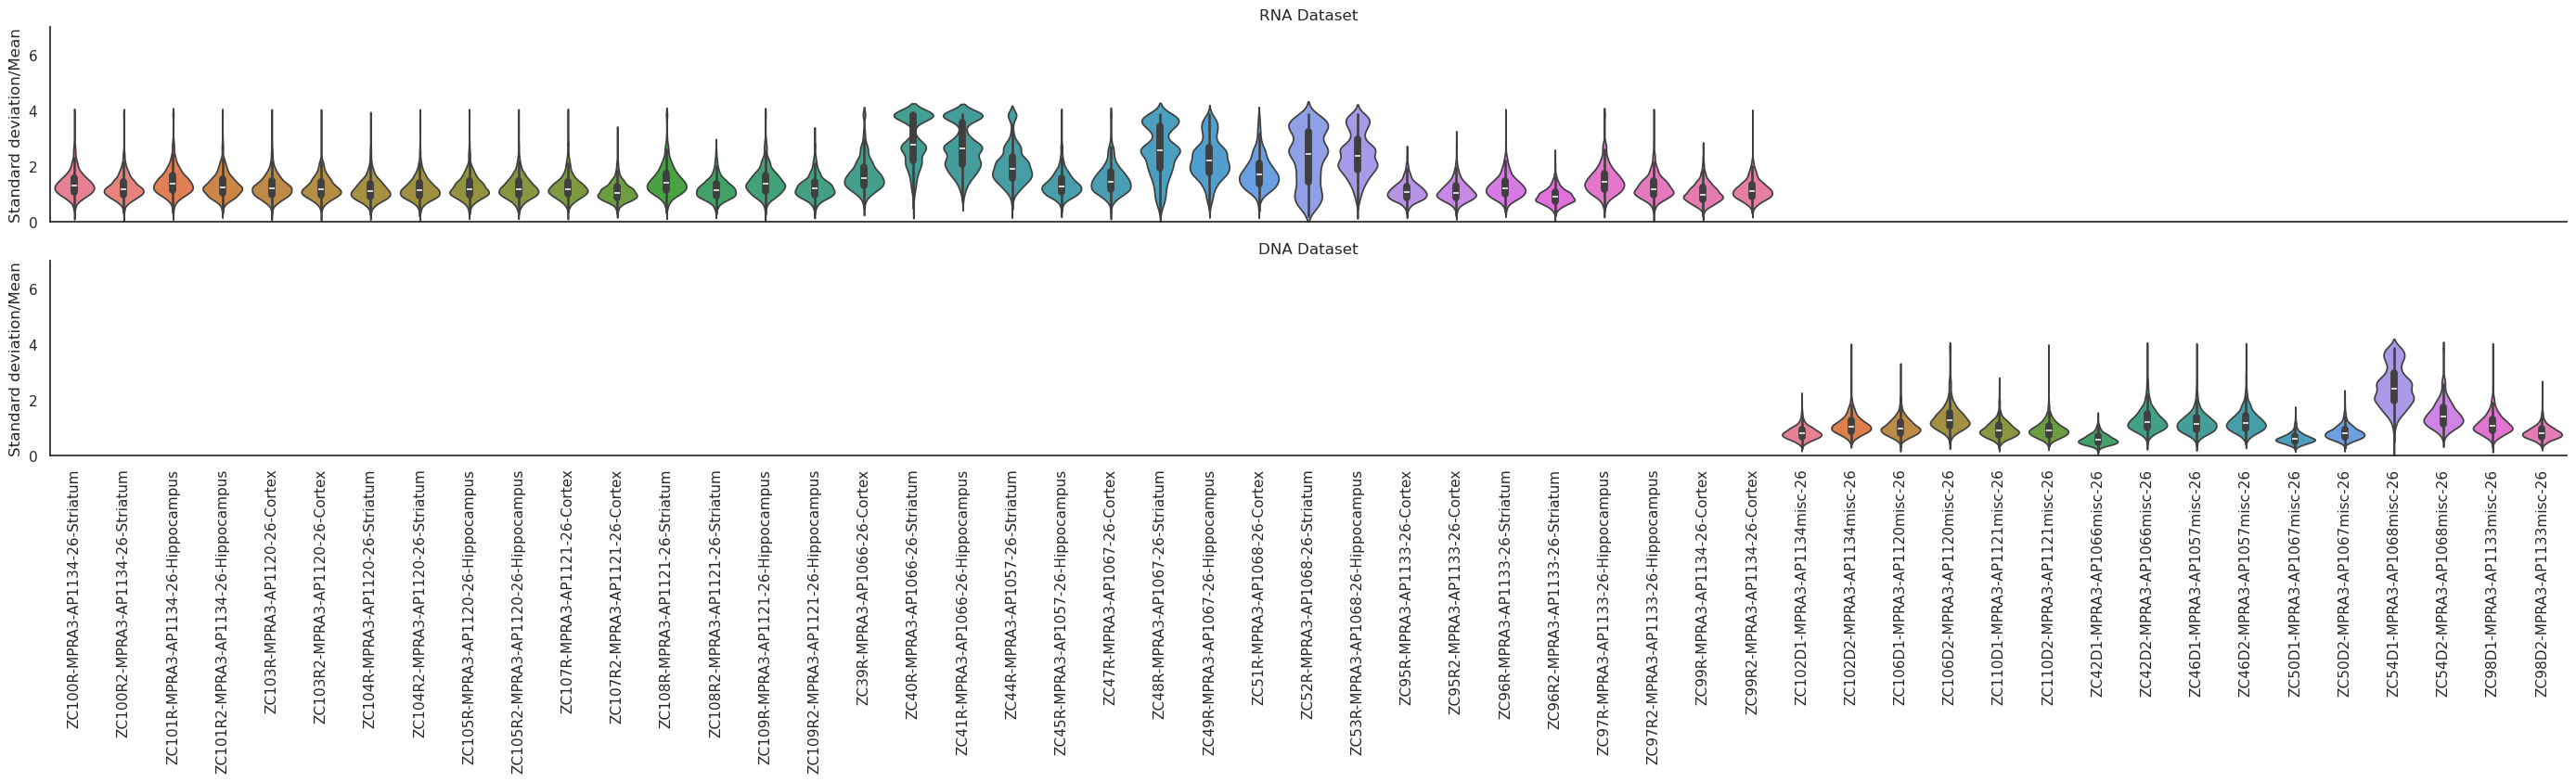

/tmp/ipykernel_21094/2059592520.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


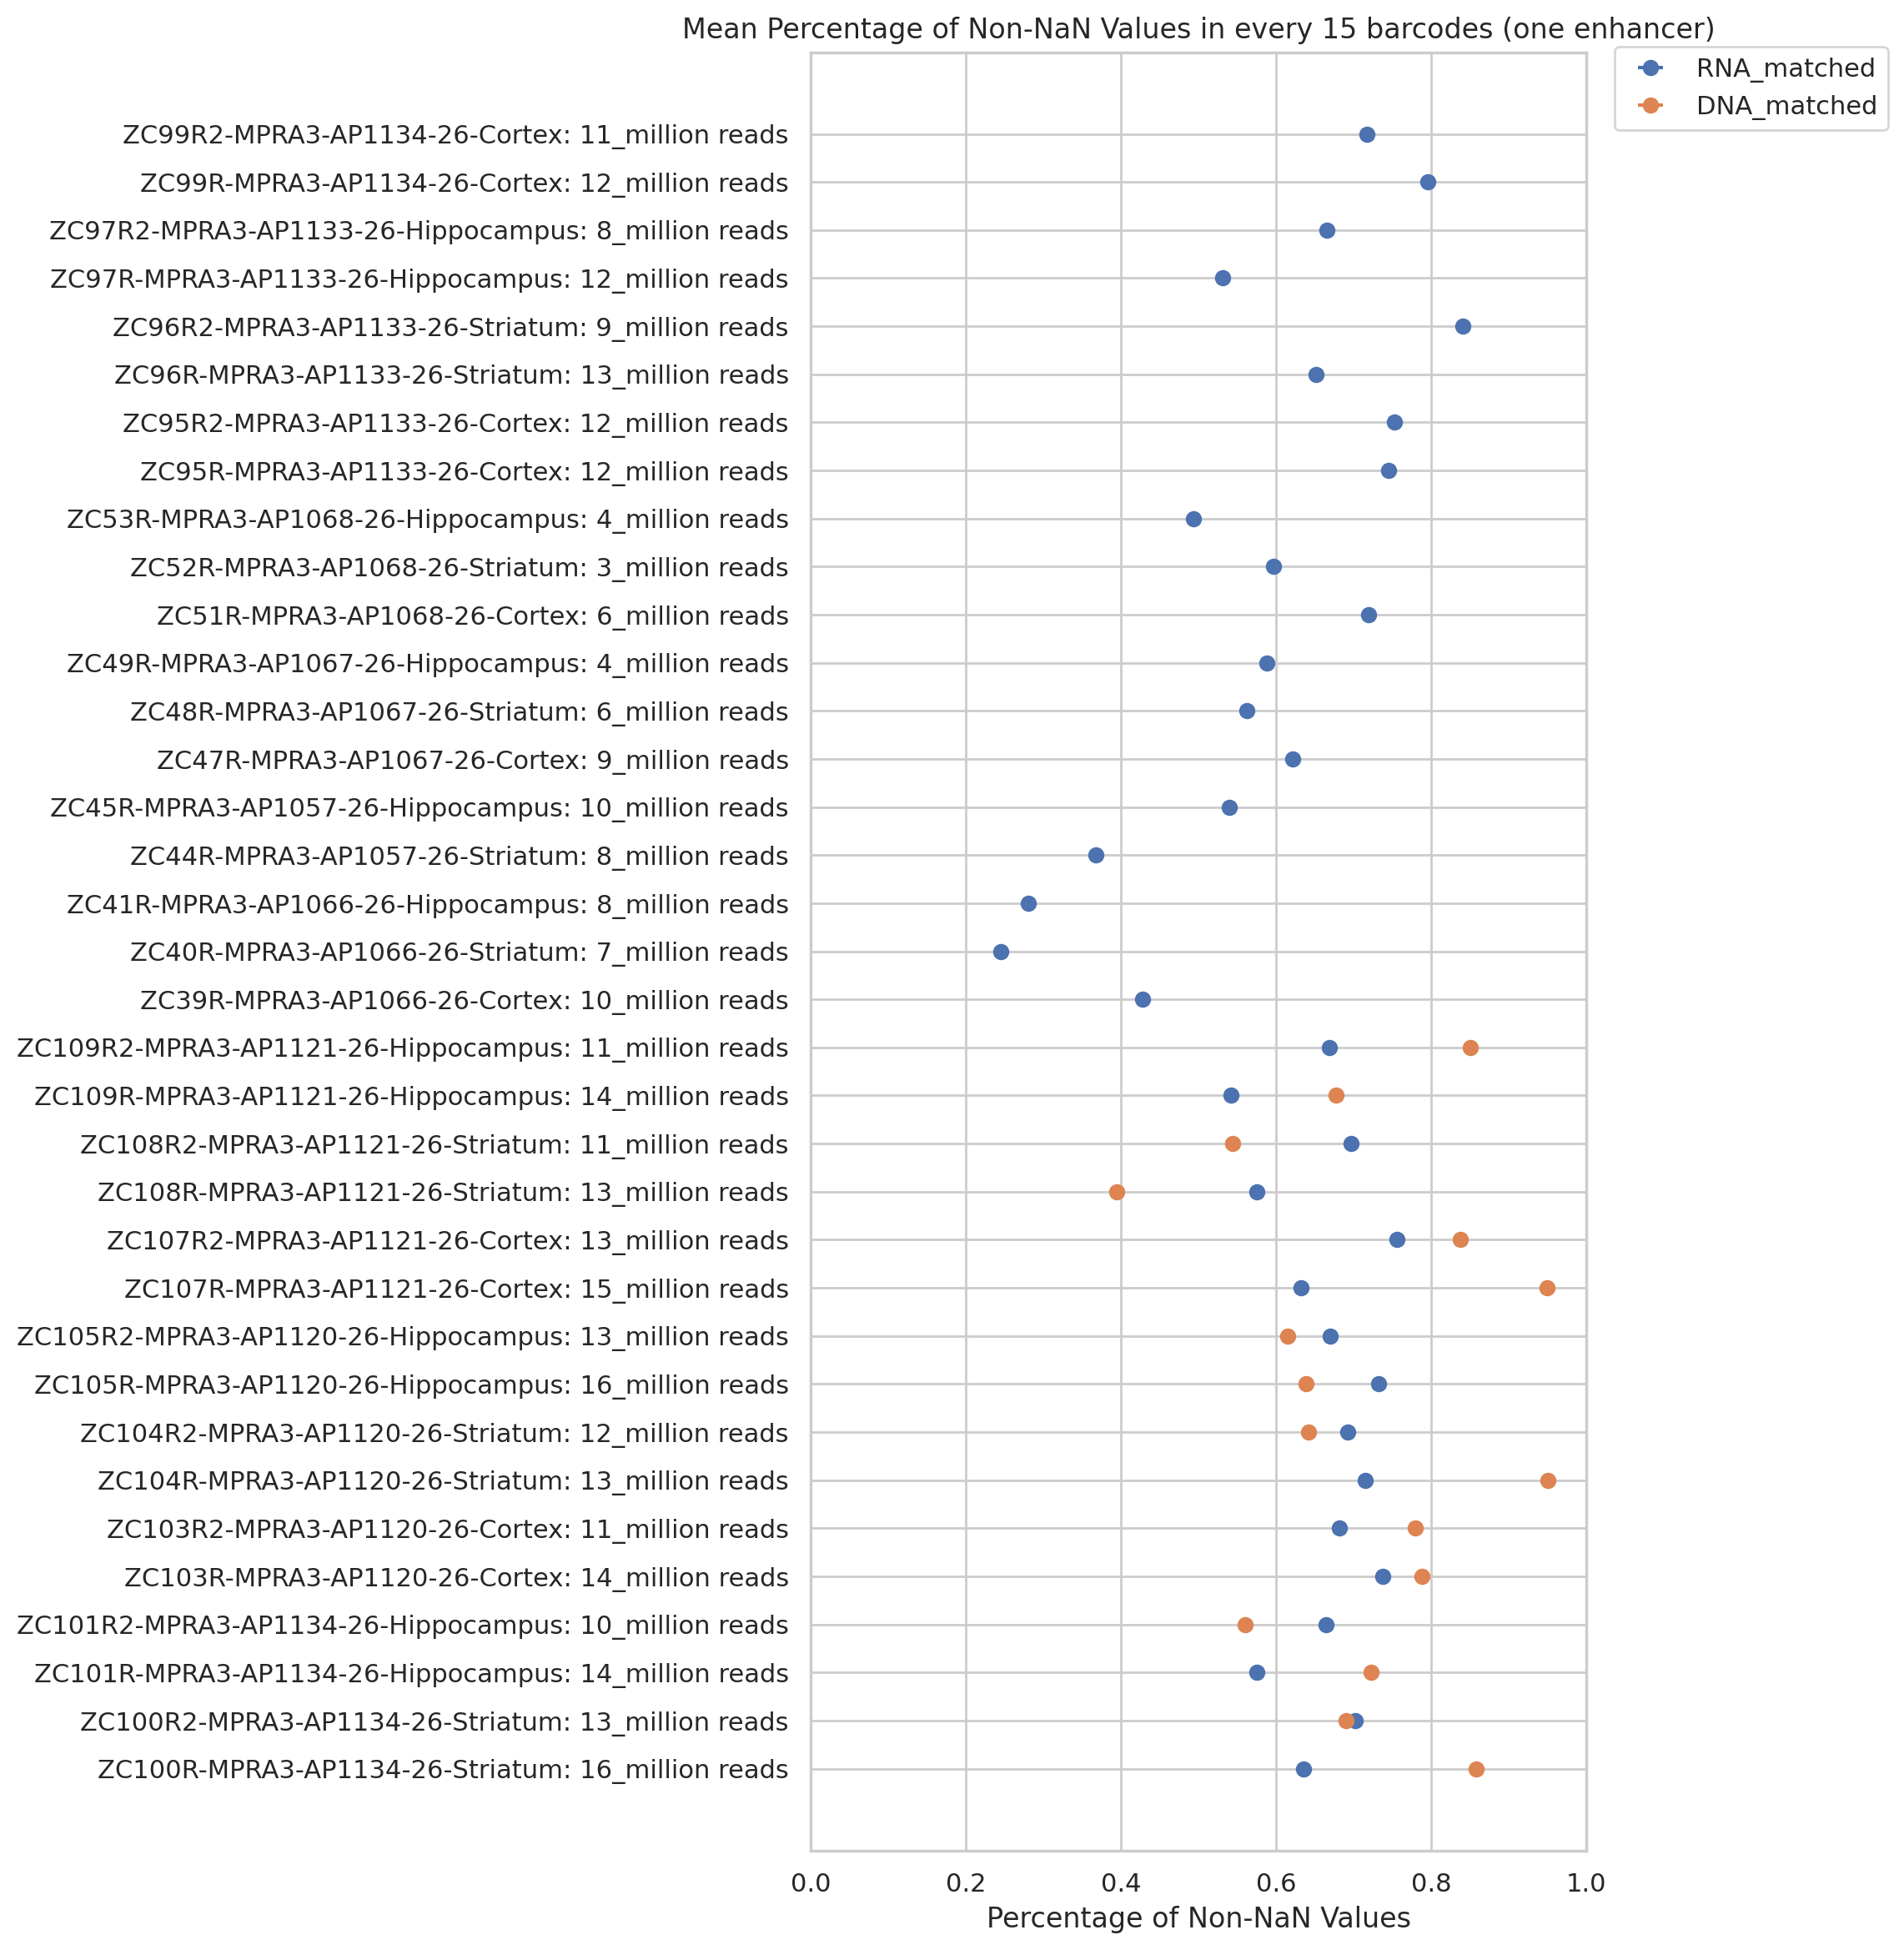

In [12]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/Brain_RNA_filtered.csv', 
    dna_file_path = 'read_counts_R1R2/Brain_DNA_filtered.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 7)
plot_barcodes_dropout(RNA_matched, DNA_matched)

# Pseudo-barcodes

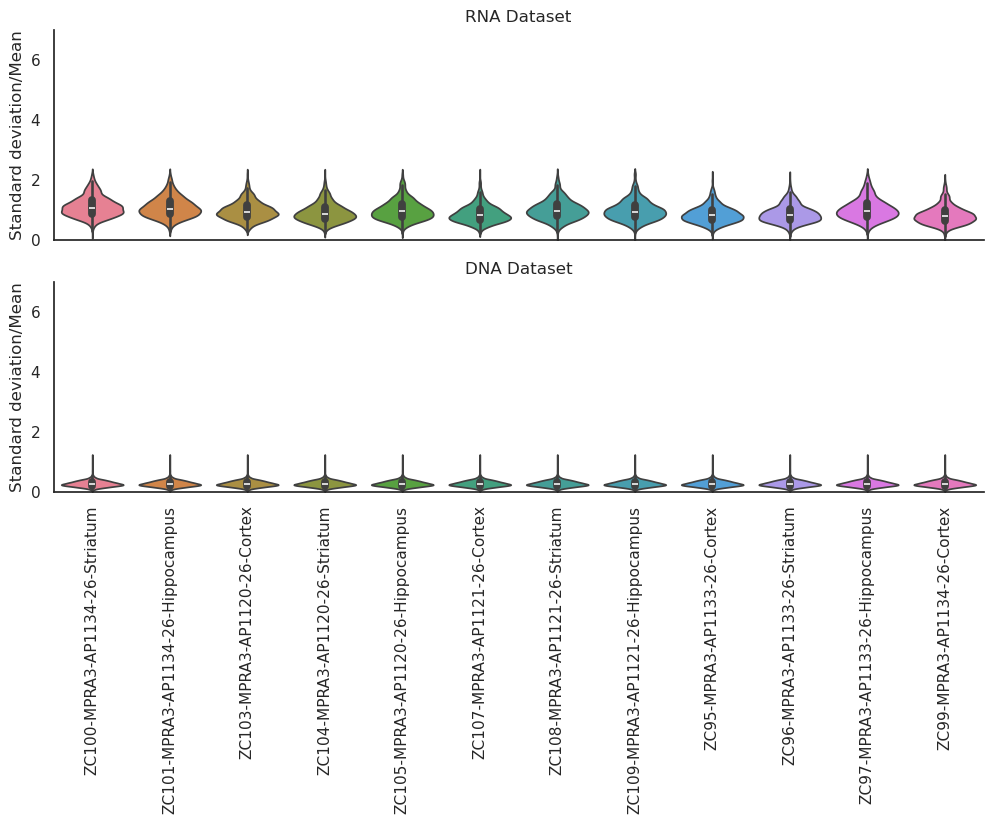

/tmp/ipykernel_21094/3993261534.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


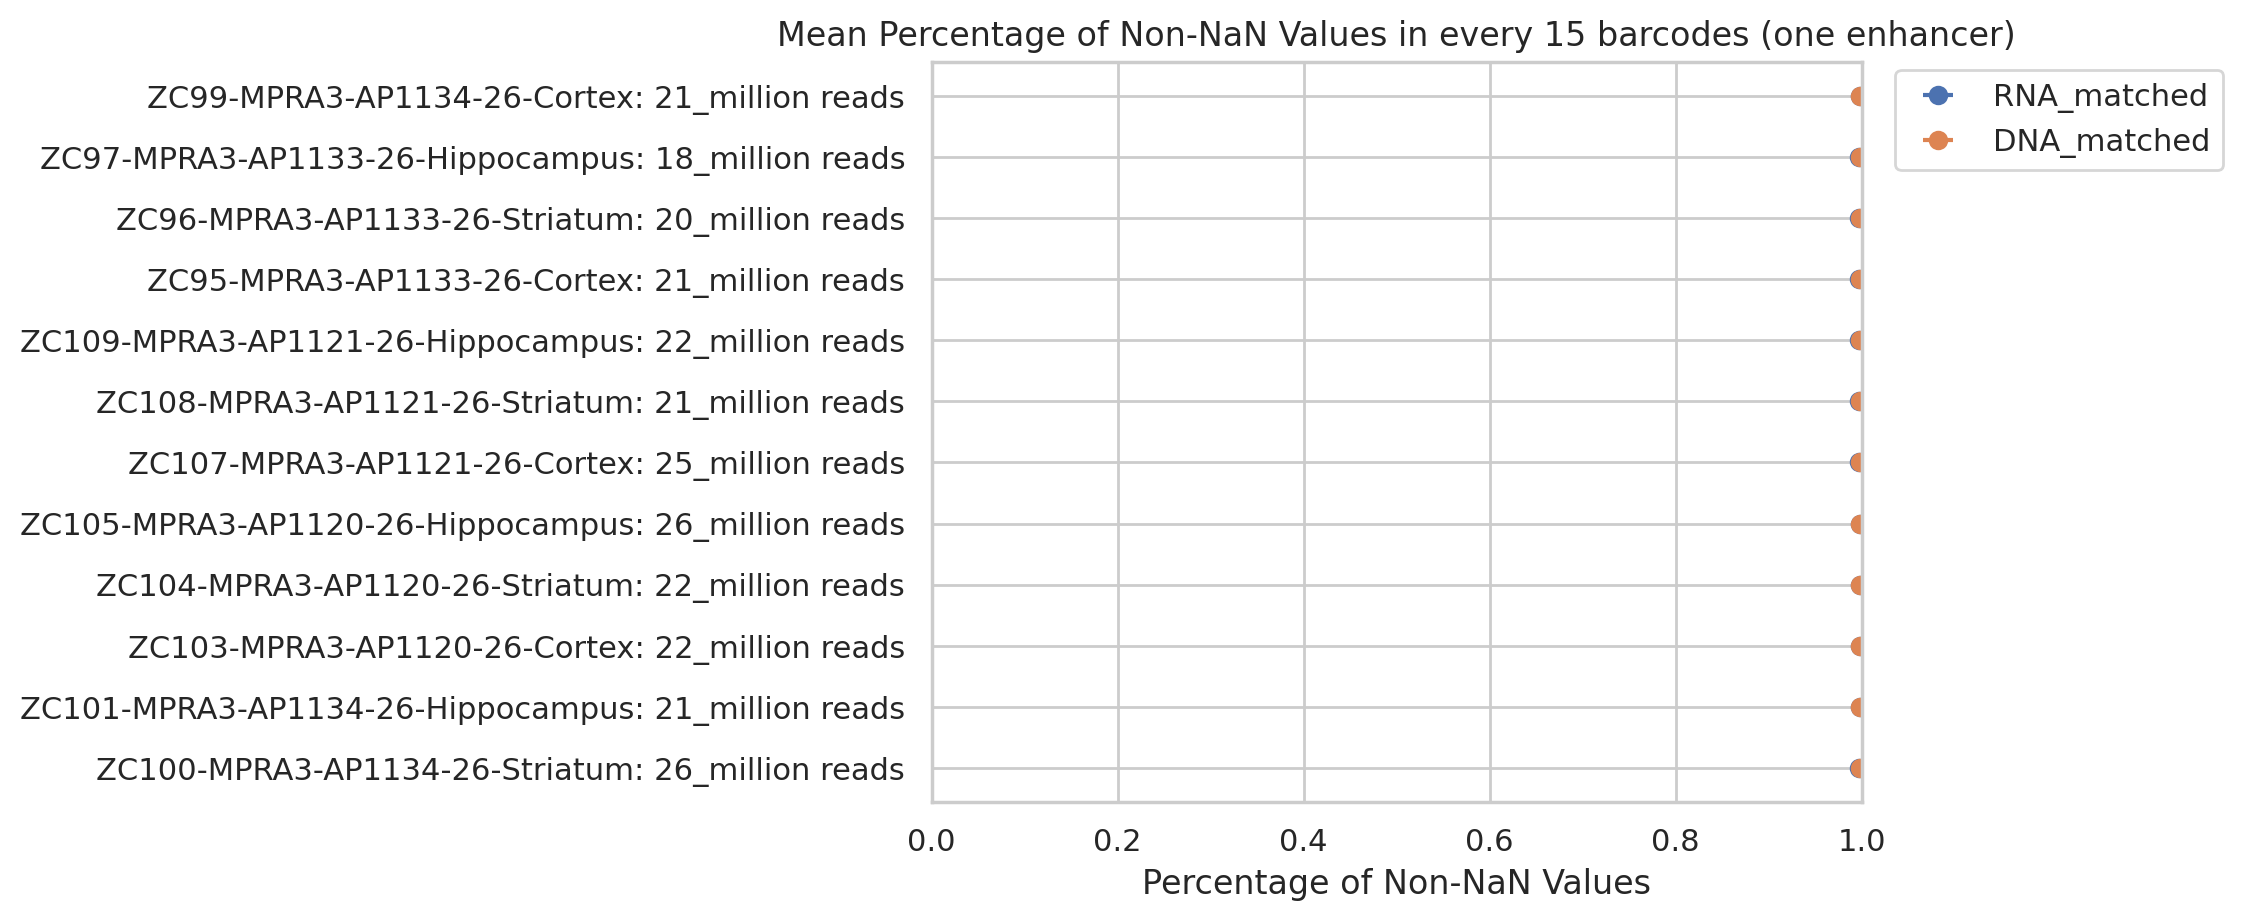

In [21]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes.csv', 
    dna_file_path = 'read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 7)
plot_barcodes_dropout(RNA_matched, DNA_matched)

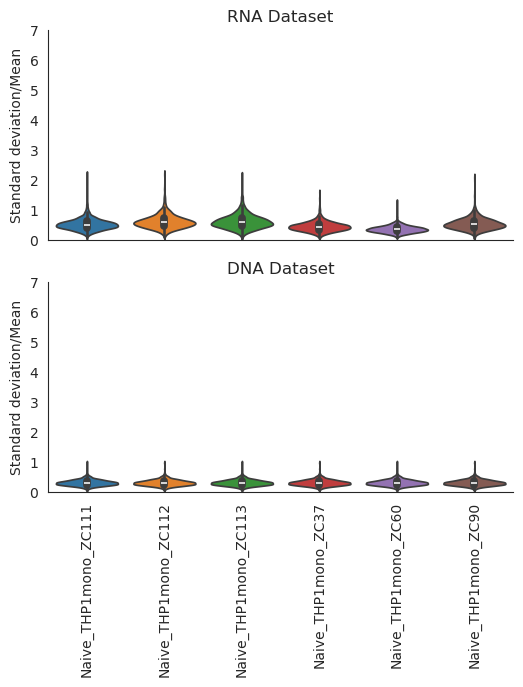

/tmp/ipykernel_54905/3993261534.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  index.append(RNA_matched.columns[i] + ": " + str(round(total_reads[i])) + "_million reads")


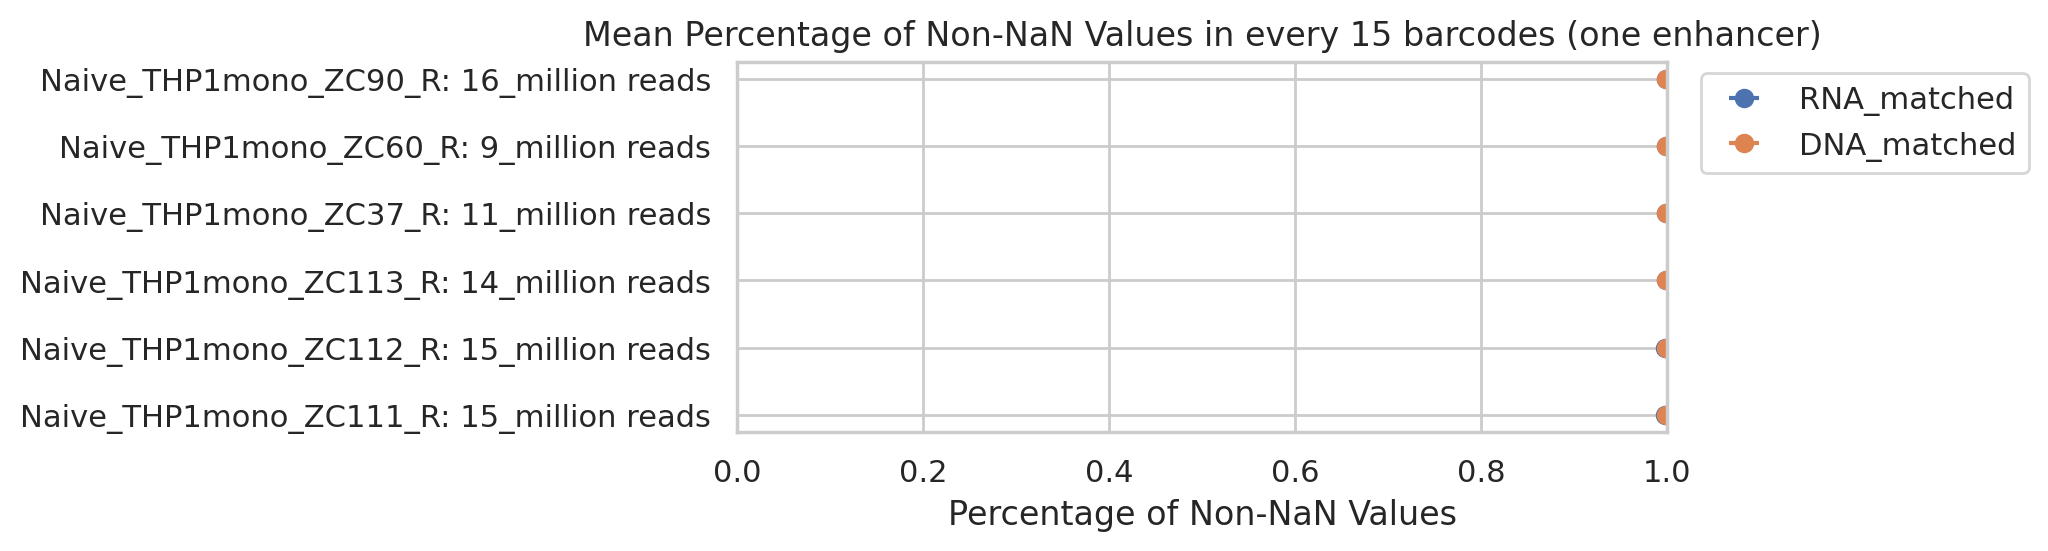

In [3]:
RNA_matched, DNA_matched = process_and_plot_data(
    rna_file_path = 'read_counts_R1R2/THP1mono20240412_RNA_matched_barcodes.csv', 
    dna_file_path = 'read_counts_R1R2/THP1mono20240412_DNA_matched_barcodes.csv', 
    enhancer_drop_file_path ='indexing/low_frequency_enhancer_drop_table_20231111.csv')

plot_sd_mean_ratio(DNA_matched, RNA_matched, width_per_element=1, height=6, dpi=100,y_lim = 7)
plot_barcodes_dropout(RNA_matched, DNA_matched)